# CRED — Modeling: Two Versions


## Part 1 — Regression on plain months

### Step 1 — Load the Monthly Totals sheet

In [ ]:
import pandas as pd

monthly = pd.read_excel('CRED_UPI_Data_Final.xlsx', sheet_name='Monthly Totals')
monthly

,Month Number,Month,Total - Volume (Mn),Total - Value (Cr)
0,1,Mar 2024,13460.81,1979266.83
1,2,Apr 2024,13304.51,1964041.35
2,3,May 2024,13883.44,2035517.75
3,4,Jun 2024,13629.10,1992273.93
4,5,Jul 2024,14263.87,2053340.36
5,6,Aug 2024,14780.89,2048869.36
6,7,Sep 2024,14852.68,2051431.95
7,8,Oct 2024,16373.53,2335087.68
8,9,Nov 2024,15277.59,2140312.71
9,10,Dec 2024,16497.60,2307565.49


### Step 2 — Split into train and test, in time order
Not randomly — train on the earlier months, test on the last few.

In [ ]:
split_at = int(len(monthly) * 0.8)

train_data = monthly.iloc[:split_at]
test_data = monthly.iloc[split_at:]

print('training on', len(train_data), 'months')
print('testing on', len(test_data), 'months')
test_data[['Month','Total - Volume (Mn)']]

training on 19 months
testing on 5 months


,Month,Total - Volume (Mn)
19,Oct 2025,20232.81
20,Nov 2025,20049.89
21,Dec 2025,21100.06
22,Jan 2026,21272.57
23,Feb 2026,19962.60


### Step 3 — Train the model

In [ ]:
from sklearn.linear_model import LinearRegression

X_train = train_data[['Month Number']]
y_train = train_data['Total - Volume (Mn)']

monthly_model = LinearRegression()
monthly_model.fit(X_train, y_train)

print('slope:', monthly_model.coef_[0])
print('intercept:', monthly_model.intercept_)

slope: 366.5983508771929
intercept: 12606.495964912283


In plain words: UPI volume has been growing by roughly this many million transactions **every single month**.

### Step 4 — Check it against the real test months

In [ ]:
X_test = test_data[['Month Number']]
y_test = test_data['Total - Volume (Mn)']

test_guesses = monthly_model.predict(X_test)

comparison = test_data[['Month','Total - Volume (Mn)']].copy()
comparison['model_guess'] = test_guesses
comparison

,Month,Total - Volume (Mn),model_guess
19,Oct 2025,20232.81,19938.462982
20,Nov 2025,20049.89,20305.061333
21,Dec 2025,21100.06,20671.659684
22,Jan 2026,21272.57,21038.258035
23,Feb 2026,19962.60,21404.856386


### Step 5 — Turn that into error numbers

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

train_guesses = monthly_model.predict(X_train)

monthly_train_mae = mean_absolute_error(y_train, train_guesses)
monthly_test_mae = mean_absolute_error(y_test, test_guesses)
monthly_test_r2 = r2_score(y_test, test_guesses)

print('train error (MAE):', round(monthly_train_mae, 1))
print('test error (MAE):', round(monthly_test_mae, 1))
print('test R2:', round(monthly_test_r2, 3))

train error (MAE): 373.0
test error (MAE): 530.9
test R2: -0.628


### Step 6 — Forecast forward (monthly version)

In [ ]:
last_month_number = monthly['Month Number'].max()
future_month_numbers = [last_month_number + 1, last_month_number + 2, last_month_number + 3]
monthly_forecast = monthly_model.predict(pd.DataFrame({'Month Number': future_month_numbers}))

for m, guess in zip(['Mar 2026','Apr 2026','May 2026'], monthly_forecast):
    print(m, ':', round(guess, 1), 'Mn')

Mar 2026 : 21771.5 Mn
Apr 2026 : 22138.1 Mn
May 2026 : 22504.7 Mn


## Part 2 — Regression on 3-month averages

### Step 7 — Load the 3-Month Averages sheet

In [ ]:
quarters = pd.read_excel('CRED_UPI_Data_Final.xlsx', sheet_name='3-Month Averages')
quarters

,Quarter Number,Period (3 Months),Avg Total Volume (Mn),Avg Total Value (Cr)
0,1,Mar 2024 - May 2024,13549.586667,1.992942e+06
1,2,Jun 2024 - Aug 2024,14224.620000,2.031495e+06
2,3,Sep 2024 - Nov 2024,15501.266667,2.175611e+06
3,4,Dec 2024 - Feb 2025,16374.060000,2.272599e+06
4,5,Mar 2025 - May 2025,18008.060000,2.441152e+06
5,6,Jun 2025 - Aug 2025,18971.726667,2.440763e+06
6,7,Sep 2025 - Nov 2025,19857.283333,2.585252e+06
7,8,Dec 2025 - Feb 2026,20778.410000,2.739503e+06


### Step 8 — Split train/test
Only 8 rows here, so an 80/20 split leaves barely 1-2 test points — I'm using 6 for training and the last 2 for testing instead, which makes more sense for this few data points.

In [ ]:
train_q = quarters.iloc[:6]
test_q = quarters.iloc[6:]

print('training on', len(train_q), 'periods')
print('testing on', len(test_q), 'periods')
test_q[['Period (3 Months)','Avg Total Volume (Mn)']]

training on 6 periods
testing on 2 periods


,Period (3 Months),Avg Total Volume (Mn)
6,Sep 2025 - Nov 2025,19857.283333
7,Dec 2025 - Feb 2026,20778.410000


### Step 9 — Train the model

In [ ]:
X_train_q = train_q[['Quarter Number']]
y_train_q = train_q['Avg Total Volume (Mn)']

quarter_model = LinearRegression()
quarter_model.fit(X_train_q, y_train_q)

print('slope (per 3-month period):', quarter_model.coef_[0])
print('intercept:', quarter_model.intercept_)

slope (per 3-month period): 1123.823238095238
intercept: 12171.505333333334


### Step 10 — Check it against the real test periods

In [ ]:
X_test_q = test_q[['Quarter Number']]
y_test_q = test_q['Avg Total Volume (Mn)']

test_guesses_q = quarter_model.predict(X_test_q)

comparison_q = test_q[['Period (3 Months)','Avg Total Volume (Mn)']].copy()
comparison_q['model_guess'] = test_guesses_q
comparison_q

,Period (3 Months),Avg Total Volume (Mn),model_guess
6,Sep 2025 - Nov 2025,19857.283333,20038.268000
7,Dec 2025 - Feb 2026,20778.410000,21162.091238


### Step 11 — Error numbers for the averaged version

In [ ]:
train_guesses_q = quarter_model.predict(X_train_q)

quarter_train_mae = mean_absolute_error(y_train_q, train_guesses_q)
quarter_test_mae = mean_absolute_error(y_test_q, test_guesses_q)
quarter_test_r2 = r2_score(y_test_q, test_guesses_q)

print('train error (MAE):', round(quarter_train_mae, 1))
print('test error (MAE):', round(quarter_test_mae, 1))
print('test R2:', round(quarter_test_r2, 3))

train error (MAE): 176.3
test error (MAE): 282.3
test R2: 0.576


### Step 12 — Compare both versions side by side

In [ ]:
print('MONTHLY VERSION   -> train MAE:', round(monthly_train_mae,1), '| test MAE:', round(monthly_test_mae,1), '| test R2:', round(monthly_test_r2,3))
print('3-MONTH AVG VERSION -> train MAE:', round(quarter_train_mae,1), '| test MAE:', round(quarter_test_mae,1), '| test R2:', round(quarter_test_r2,3))

MONTHLY VERSION   -> train MAE: 373.0 | test MAE: 530.9 | test R2: -0.628
3-MONTH AVG VERSION -> train MAE: 176.3 | test MAE: 282.3 | test R2: 0.576


**What to look for:** the 3-month average version smooths out single-month noise (like the Feb 2026 dip), so its line might fit more consistently — but it only has 8 data points total, so its test R² is less statistically reliable than the monthly version's. Worth reporting both and explaining the trade-off rather than picking one and hiding the other.

### Step 13 — See both lines together

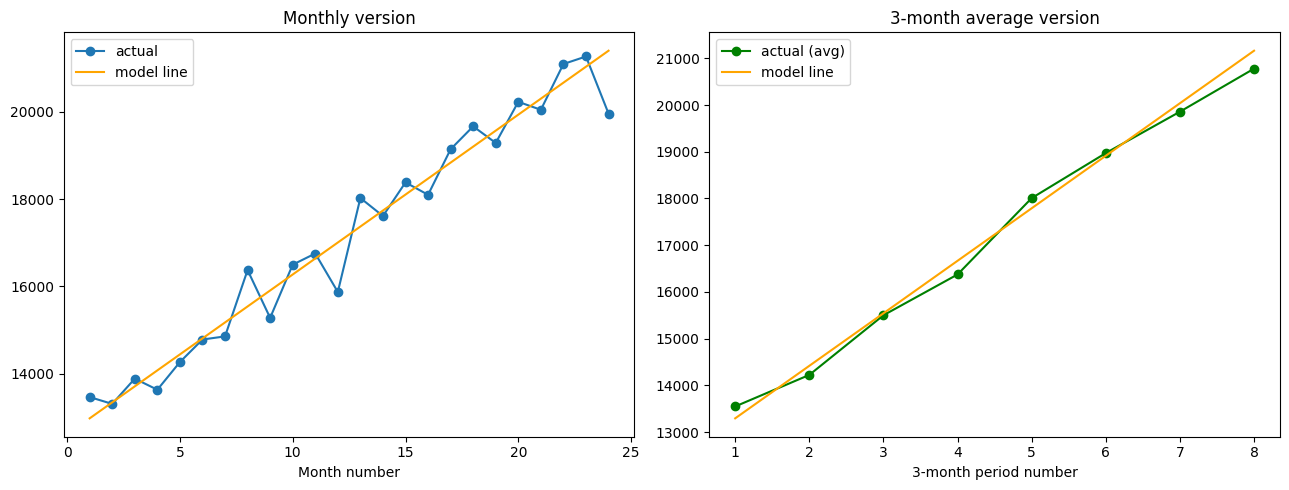

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13,5))

all_monthly_guesses = monthly_model.predict(monthly[['Month Number']])
axes[0].plot(monthly['Month Number'], monthly['Total - Volume (Mn)'], marker='o', label='actual')
axes[0].plot(monthly['Month Number'], all_monthly_guesses, color='orange', label='model line')
axes[0].set_title('Monthly version')
axes[0].set_xlabel('Month number')
axes[0].legend()

all_quarter_guesses = quarter_model.predict(quarters[['Quarter Number']])
axes[1].plot(quarters['Quarter Number'], quarters['Avg Total Volume (Mn)'], marker='o', color='green', label='actual (avg)')
axes[1].plot(quarters['Quarter Number'], all_quarter_guesses, color='orange', label='model line')
axes[1].set_title('3-month average version')
axes[1].set_xlabel('3-month period number')
axes[1].legend()

plt.tight_layout()
plt.show()

### Step 14 — Save both outputs for the dashboard/memo

In [ ]:
monthly['Predicted Volume'] = monthly_model.predict(monthly[['Month Number']])
quarters['Predicted Avg Volume'] = quarter_model.predict(quarters[['Quarter Number']])

monthly.to_csv('monthly_model_output.csv', index=False)
quarters.to_csv('quarterly_model_output.csv', index=False)

print('saved monthly_model_output.csv and quarterly_model_output.csv')

saved monthly_model_output.csv and quarterly_model_output.csv
